<div style="background-color: #d9ffd4; padding: 20px; border-radius: 10px;">
    <h1 style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center; margin-bottom: 5px;">
        Proyecto Computacional: Campo Eléctrico
    </h1>
    <p style="color: #2F4F4F; font-family: Calibri, Courier, monospace; text-align: center; font-size: 24px; margin-top: 0;">
        Modelación Numérica mediante la Ecuación de Poisson
    </p>
    <p style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center; font-size: 18px; margin-top: 15px;">
        <strong>Integrantes:</strong> Diego Rivera y Miguel Manriquez
    </p>
</div>

En el estudio del ámbito del electromagnetismo, la noción del campo eléctrico representa un gran desafío pedagógico debido a su naturaleza abstracta y la complejidad del cálculo vectorial que esta requiere. Normalmente, se aprecia como una entidad intangible que cubre el espacio, lo que puede dificultad su comprensión teórica. Por ello, nuestro grupo propone una solución a este problema basada en la generación de mapas de potencial y representaciones vectoriales, permitiendo así al usuario visualizar y comprender de forma intuitiva la dinámica y el comportamiento del campo.

En este proyecto, abordaremos el problema determinando numéricamente el comportamiento eléctrico en el espacio generado por distribuciones de carga continuas. El objetivo principal es encontrar una solución computacional para el potencial eléctrico escalar y, a partir de él, deducir el campo vectorial correspondiente.

A menudo, las configuraciones de carga carecen de la simetría necesaria para ser resueltas de forma analítica exacta mediante la Ley de Gauss. Por consiguiente, la modelación computacional resulta indispensable. Analizaremos una región espacial, estableceremos condiciones de contorno y aplicaremos métodos iterativos para visualizar cómo interactúa el campo en nuestra malla de estudio.

Quieremos determinar numéricamente el potencial eléctrico generado por distribuciones de carga continuas y, a partir de él, calcular el campo eléctrico mediante el gradiente. La ecuación fundamental a resolver es la ecuación de Poisson:
$$
\nabla^{2}\phi(r) = -\frac{\rho(r)}{\epsilon_{0}}
$$  
Donde se define:  
$\phi(r)$: Potencial eléctrico (campo escalar).  
$\rho(r)$: Densidad de carga espacial.  
$\epsilon_{0}$: Permitividad del vacío.  
Una vez que obtengamos el campo escalar $\phi(r)$ en cada punto del espacio, podemos analizar el campo eléctrico $\vec{E}$. Sabemos que el campo eléctrico se define como el gradiente negativo del potencial:  
$$
\vec{E} = -\vec{\nabla}\phi = \left( -\frac{\partial \phi}{\partial x}, -\frac{\partial \phi}{\partial y} \right)
$$  
El gradiente proporcionará la dirección de la fuerza eléctrica y la tasa de máximo cambio del potencial en el espacio.


In [4]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos y de la malla
metros = 5 # Unidad de cada espacio
Lx, Ly = 1.2 * metros, 1.2 * metros # Unidad fisica de cada espacio

Mx, My = 200, 200 # Tamaño de la malla
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12  # Permitividad del vacío (F/m)

# Discretización del espacio

# Se crean los arrays uniformemente espaciados
x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
# Hace que los arrays de 1D los junte en uno de 2D
X, Y = np.meshgrid(x, y)
# Formula del radio del circulo aplico al meshgrid
R = np.sqrt(X**2 + Y**2)

# Definición de la densidad de carga rho (Anillo)

r_out = 2.0 # Radio exterior en metros
r_in = 1.9  # Radio interior en metros
mask_ring = (R <= r_out) & (R >= r_in) 

# Genera la densidad del mismo tamaño de la malla 
rho = np.zeros((My, Mx))
# Establecemos un valor arbitrario de la carga
Q = 1e-9 # Carga en Coulomb
rho[mask_ring] = Q # Aplicamos la carga solo en la región del anillo

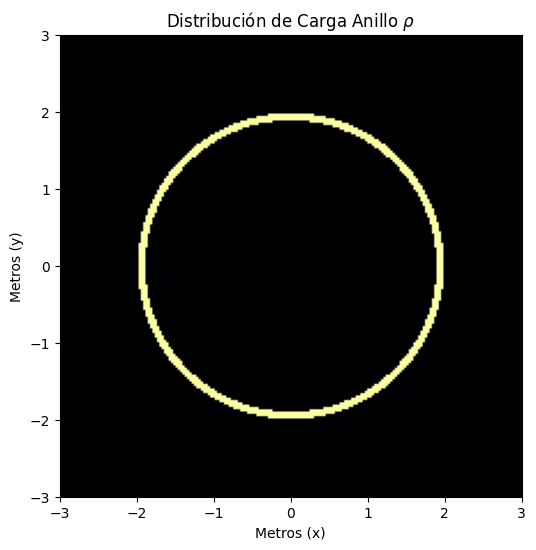

In [38]:
# Figura cuadrada
plt.figure(figsize=(6,6))
# Titulo 
plt.title(r"Distribución de Carga Anillo $\rho$")
# Se usa extent para que los ejes sean metros reales
plt.imshow(rho, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='inferno')
plt.xlabel('Metros (x)')
plt.ylabel('Metros (y)')
# Quitamos la rejilla para que se vea más limpio
plt.grid(False)
plt.show()

## Condiciones de frontera:  
Antes de iterar, debemos establecer las condiciones de contorno de nuestra región de estudio. Para simular que este anillo está aislado en el espacio, estableceremos que en los límites físicos de nuestra malla el potencial eléctrico decae a cero ($\phi \rightarrow 0$) a grandes distancias.  
En nuestra implementación, nos aseguraremos de que los bordes perimetrales de la matriz del potencial phi se mantengan estrictamente en $0 \text{ V}$ durante todo el proceso de cálculo.

In [5]:
# Inicializamos la matriz del potencial en cero
phi = np.zeros((Mx, My))

# Definimos máscaras booleanas para respetar las fronteras y optimizar el cálculo.
# La matriz "interior" será False en los bordes, protegiendo así la condición phi=0
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True

<div style="background-color: #7eaab0; color: black; padding: 10px; border-radius: 5px;">  
En este contexto, el objetivo de esta parte del proyecto es encontrar soluciones aproximadas de la ecuación de Poisson mediante métodos numéricos, específicamente utilizando el método de diferencias finitas centradas.  
</div>  

Para ello, discretizaremos nuestra región espacial en una malla regular 2D con un paso constante $\Delta x$ y $\Delta y$.  
Aproximamos el Laplaciano mediante diferencias finitas, el laplaciano se aproxima como:
$$
\nabla^{2}\phi_{i,j} \approx \frac{\phi_{i+1,j} - 2\phi_{i,j} + \phi_{i-1,j}}{\Delta x^{2}} + \frac{\phi_{i,j+1} - 2\phi_{i,j} + \phi_{i,j-1}}{\Delta y^{2}}
$$


<Figure size 600x600 with 0 Axes>

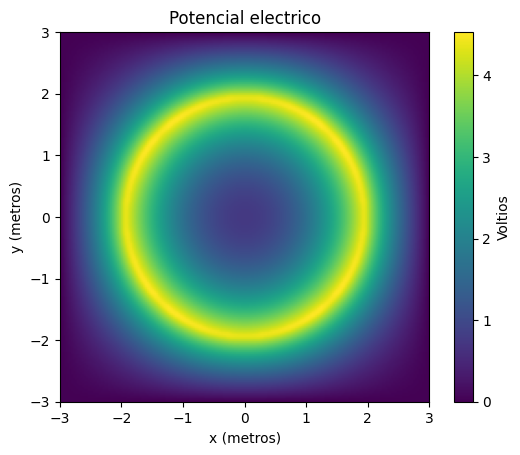

In [11]:
# Se aplica las diferencias finitas usando vectorización (Es menos tardado y optimo que usando 2 ciclos for) ((recordar que estamos en cartesianas))
for _ in range(400):
    phi[1:-1,1:-1] = 1/4*(phi[1:-1,2:] + phi[1:-1,:-2] + phi[2:,1:-1] + phi[:-2,1:-1] + (h**2 * rho[1:-1,1:-1])/e_0 )

plt.figure(figsize=(6,6))

fig,ax = plt.subplots(1,1)
p = ax.imshow(phi,extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin="lower",cmap="viridis")
ax.set_title("Potencial electrico")
ax.set_xlabel("x (metros)")
ax.set_ylabel("y (metros)")
plt.colorbar(p,ax=ax,label="Voltios")
plt.show()

## Soluciones numéricas:  
Despejando $\phi_{i,j}$ de la ecuación discretizada, nos encontramos con que el valor del potencial en una celda depende del valor de sus vecinas. Esto crea un sistema de miles de ecuaciones simultáneas. Para resolverlo, utilizamos métodos iterativos.  
Existen distintos métodos numéricos para actualizar esta malla. A continuación, implementaremos y compararemos dos de ellos para observar su eficiencia computacional.
### El Método de Jacobi (La versión inicial):
El método de Jacobi es el enfoque más básico e intuitivo. En cada iteración, se calcula el nuevo valor de una celda utilizando únicamente los valores que tenían sus vecinas en el turno anterior. En Python, podemos evitar los lentos ciclos for aplicando este método de forma vectorizada, es decir, operando sobre toda la matriz al mismo tiempo usando cortes (slicing) en los arreglos de NumPy.  
Para comprender cómo funciona computacionalmente, veamos su fórmula de actualización. En una malla bidimensional con paso uniforme $h = \Delta x = \Delta y$, el valor del potencial en la celda $(i,j)$ para el nuevo turno $(n+1)$ se calcula promediando a sus cuatro vecinas directas evaluadas estrictamente en el turno anterior $(n)$:  
$$
\phi_{i,j}^{(n+1)} = \frac{1}{4} \left( \phi_{i+1,j}^{(n)} + \phi_{i-1,j}^{(n)} + \phi_{i,j+1}^{(n)} + \phi_{i,j-1}^{(n)} + \frac{h^2 \rho_{i,j}}{\epsilon_0} \right)
$$  
Como se puede observar, todos los términos al lado derecho de la ecuación dependen del estado $(n)$. Es esta independencia espacial en el cálculo la que nos permite realizar la operación sobre toda la matriz al mismo tiempo (vectorización en NumPy) en lugar de evaluar celda por celda.

In [12]:
phi_jacobi = np.zeros((Mx, My))
tolerancia = 1e-5
error_jacobi = 1.0
iteraciones_jacobi = 0
max_iter = 10000

while error_jacobi > tolerancia and iteraciones_jacobi < max_iter:
    # Guardamos una copia del estado anterior
    phi_old = phi_jacobi.copy()

    # Aplicamos la ecuación de diferencias finitas de forma vectorizada
    # Promediamos los 4 vecinos y sumamos el aporte de la carga local (rho)
    phi_jacobi[1:-1, 1:-1] = 0.25 * (phi_jacobi[1:-1, 2:] + phi_jacobi[1:-1, :-2] + 
                                     phi_jacobi[2:, 1:-1] + phi_jacobi[:-2, 1:-1] + 
                                     (h**2 * rho[1:-1, 1:-1]) / e_0)

    # Calculamos el error máximo absoluto entre el turno nuevo y el viejo
    error_jacobi = np.max(np.abs(phi_jacobi - phi_old))
    iteraciones_jacobi += 1
    
print(f"Método de Jacobi: Convergencia en {iteraciones_jacobi} iteraciones.")
print(f"Error acumulado final: {error_jacobi:.2e}")

Método de Jacobi: Convergencia en 10000 iteraciones.
Error acumulado final: 5.24e-04


Al ejecutar el método de Jacobi en nuestra malla de $200\times200$, notaremos que toma una enorme cantidad de iteraciones para que la información se propague desde el anillo hacia los bordes.

Para acelerar esto, la teoría numérica nos ofrece el Método Gauss-Seidel, el cual usa la información fresca de las celdas recién calculadas de inmediato en el mismo turno a diferencia de Jacobi (que usa solo datos viejos).  
$$
\phi_{i,j}^{(n+1)} = \frac{1}{4} \left( \phi_{i+1,j}^{(n)} + \mathbf{\phi_{i-1,j}^{(n+1)}} + \phi_{i,j+1}^{(n)} + \mathbf{\phi_{i,j-1}^{(n+1)}} + \frac{h^2 \rho_{i,j}}{\epsilon_0} \right)
$$  
Si además le multiplicamos por un factor de relajación $\omega$ en la dirección en la que el valor está cambiando, obtenemos el método SOR (Sobre-relajación Sucesiva) donde $1 < \omega < 2$:
$$
\phi_{i,j}^{(n+1)} = (1 - \omega) \phi_{i,j}^{(n)} + \omega \left( \phi_{i,j}^{GS} \right)
$$

Gauss-Seidel y SOR obligan a calcular celda por celda secuencialmente, lo que rompe nuestra vectorización en NumPy.
Por ende para poder aplicar SOR y seguir manteniendo la velocidad vectorial de NumPy, dividimos nuestra malla como un tablero de ajedrez. Creamos máscaras booleanas para las "casillas rojas" y las "casillas negras". Dado que una celda roja solo tiene vecinas negras, podemos actualizar todas las rojas al mismo tiempo, recalcular los promedios, y luego actualizar todas las negras de golpe.
Veamos cómo se traduce en código:

In [13]:
# --- Parámetros de Convergencia y SOR ---
# Factor de aceleración (viene de la formula del SOR)

omega = 1.9
tolerancia = 1e-5
error_sor = 1
iteraciones_sor = 0
max_iter = 10000

# Se crea una matriz de coordenadas espaciales de I x J
I, J = np.indices(phi.shape)

# Se realizan máscaras booleanas para proteger los bordes (que deben quedar en 0V)
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True

# Separamos el interior en celdas rojas (pares) y negras (impares)
mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < max_iter:
    # Copia del estado anterior para medir el error
    phi_old = phi.copy()
    
    # --- PASO 1: Actualizar las casillas ROJAS ---
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Aplicamos la fórmula SOR solo a la máscara roja
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # --- PASO 2: Actualizar las casillas NEGRAS ---
    # Recalculamos los promedios usando la nueva información fresca de las celdas rojas
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho[1:-1, 1:-1] / e_0))
    
    # Aplicamos la fórmula SOR solo a la máscara negra
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    # Medimos la diferencia máxima para verificar si ya convergimos
    error_sor = np.max(np.abs(phi - phi_old))
    iteraciones_sor += 1

print(f"Método SOR (Rojo-Negro): Convergencia en {iteraciones_sor} iteraciones.")
print(f"Error acumulado final: {error_sor:.2e}")


Método SOR (Rojo-Negro): Convergencia en 1775 iteraciones.
Error acumulado final: 9.99e-06


## Campo eléctrico:  
Una vez obtenido $\phi$ en cada punto, el campo eléctrico se calcula como el gradiente negativo del potencial escalar:  
$$
\vec{E} = -\vec{\nabla}\phi
$$
Para lograr esto con alta eficiencia computacional, aproximamos el gradiente mediante diferencias finitas centradas utilizando la función vectorizada np.gradient de NumPy, considerando nuestros pasos espaciales $dx$ y $dy$.

In [14]:
# El campo eléctrico es el gradiente negativo del potencial escalar
Ey, Ex = np.gradient(-phi, dy, dx)

# Calculamos la magnitud del campo vectorial
E_mag = np.sqrt(Ex**2 + Ey**2)

A continuación, graficaremos los resultados para interpretar físicamente el modelo. Presentamos mapas de intensidad tanto del potencial escalar $\phi$ como de la magnitud del campo eléctrico $|\vec{E}|$, finalizando con las líneas de flujo vectorial.

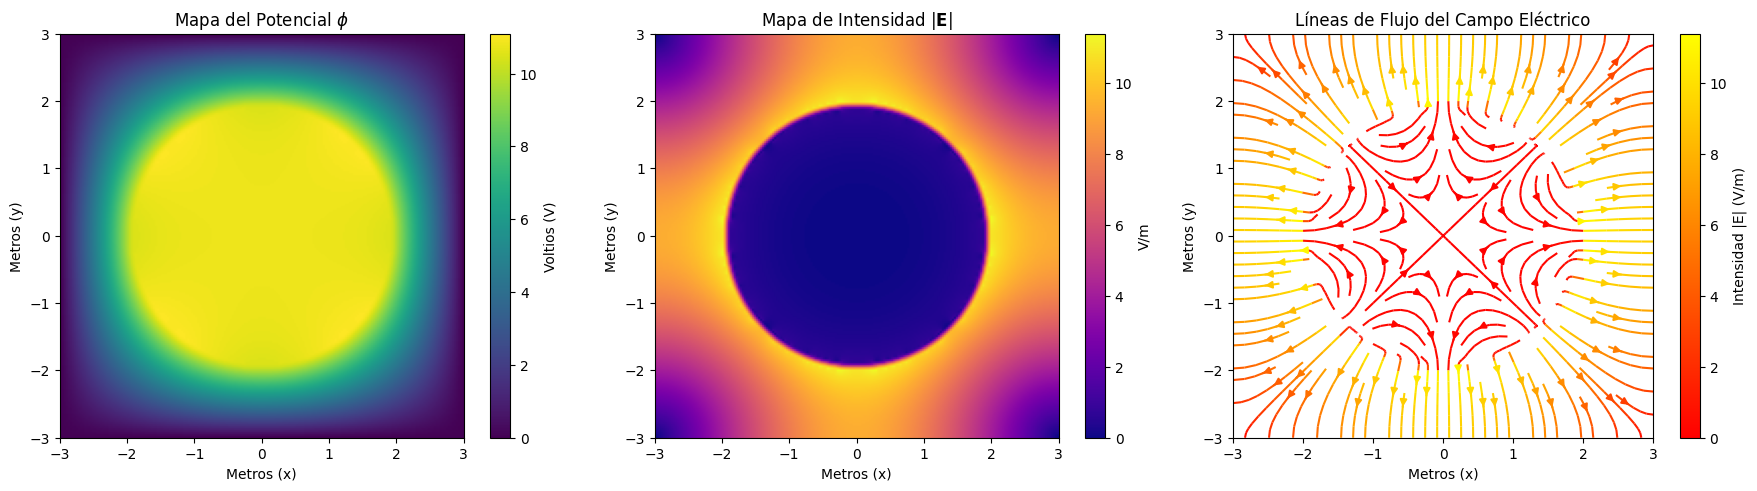

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mapa del potencial escalar
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de intensidad de la magnitud del campo
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma')
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Panel 3: Líneas de flujo del campo eléctrico
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.2, linewidth=1.5)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

### Caso densidad no uniforme  
Para poder ver el funcionamiento del método numérico, probaremos el caso de un Anillo dipolar.  
En esta configuración la densidad de carga $\rho$ no es uniforme, si no que esta varía a lo largo del perimetro del anillo dependiendo de un ángulo $\theta$.  
En este caso utilizaremos la función:
$$
\rho(r, \theta) = Q_{0} \cdot \sin(\theta)
$$
Físicamente, esto representa un anillo donde el polo norte concentra una carga positiva, y el polo sur concentra una carga negativa, mientras que las zonas ecuatoriales son neutras. Al igual que en el caso anterior, usaremos el algoritmo de resolución SOR el cual se mantiene intacto, demostrando la flexibilidad del método.

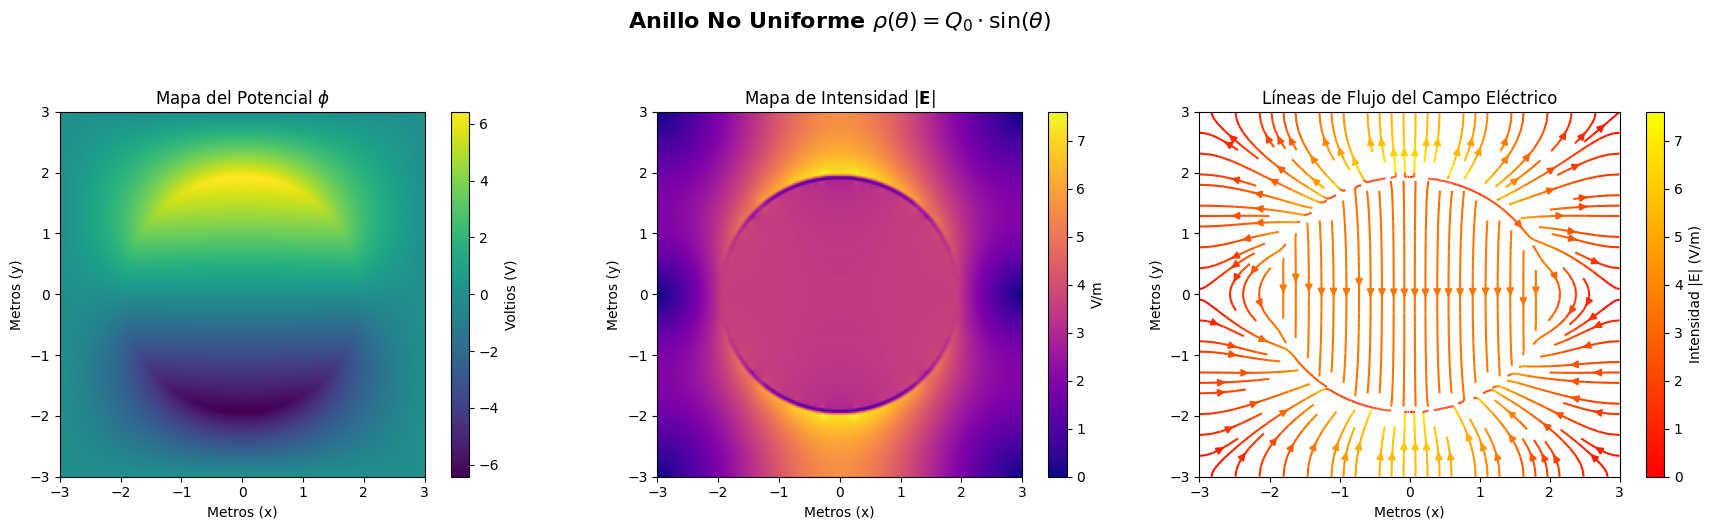

In [17]:
# Anillo de densidad no uniforme

# Configuración de la Malla
metros = 5 
Lx, Ly = 1.2 * metros, 1.2 * metros 
Mx, My = 200, 200 
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
X, Y = np.meshgrid(x, y)

# Geometría Anular + Densidad Angular Variable
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X) # Calculamos el ángulo polar theta para cada punto

r_out = 2.0 
r_in = 1.9  
mask_ring = (R <= r_out) & (R >= r_in) 

rho_variable = np.zeros((My, Mx))
Q0 = 1e-9    # Constante de magnitud de carga

# Asignamos la carga SOLO dentro del anillo, pero variando según el seno del ángulo
rho_variable[mask_ring] = Q0 * np.sin(Theta[mask_ring])

# Resolución Numérica SOR
phi = np.zeros((Mx, My))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

I, J = np.indices(phi.shape)
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True 
mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 10000:
    phi_old = phi.copy()
    
    # Actualización ROJAS
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_variable[1:-1, 1:-1] / e_0))
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_variable[1:-1, 1:-1] / e_0))
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial
Ey, Ex = np.gradient(-phi, dy, dx)
E_mag = np.sqrt(Ex**2 + Ey**2)

# Visualización
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Anillo No Uniforme $\rho(\theta) = Q_{0} \cdot \sin(\theta)$", 
             fontsize=16, fontweight='bold', y=1.05)

# Panel 1: Mapa del potencial escalar ('seismic' para ver positivo/negativo)
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de intensidad de la magnitud del campo
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma')
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Panel 3: Líneas de flujo del campo eléctrico
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.2, linewidth=1.5)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

## Superposición de geometrías con diferentes densidades.
Usaremos el modelo númerico para probar diferentes configuraciones complejas mediante el principio de superposicion directa en la matríz de densidad.
Diseñamos un sistema compuesto por dos geometrías simultáneas con propiedades distintas:  
* Un disco en el centro con densidad uniforme: Un círculo sólido de radio $r \le 0.5 \text{ m}$ con una densidad de carga positiva constante $\rho_{1} = Q_{0}$.
* Un anillo exterior con densidad no uniforme: Anillo de radio $1.8 \le r \le 2.0 \text{ m}$ con una densidad de carga dipolar que varía horizontalmente según el coseno del ángulo polar: $\rho_{2}(\theta) = 2 Q_{0} \cdot \cos(\theta)$.


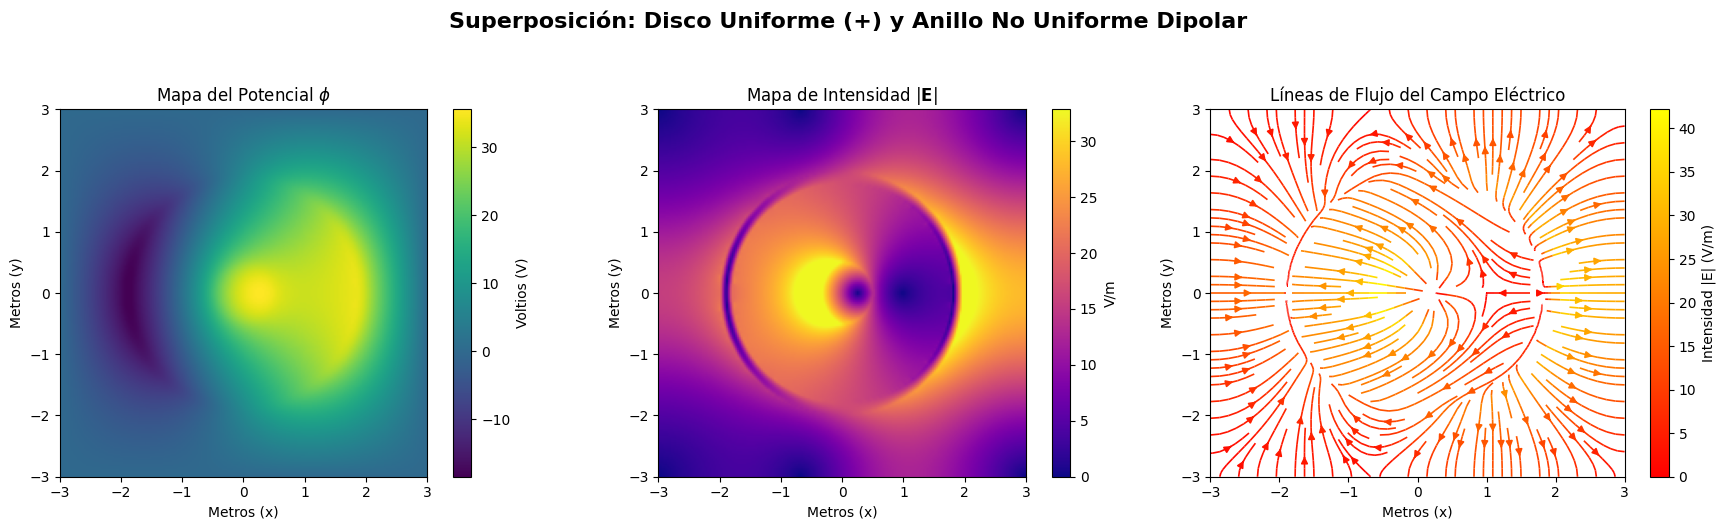

In [18]:
# Configuración de la Malla
metros = 5 
Lx, Ly = 1.2 * metros, 1.2 * metros 
Mx, My = 200, 200 
dx, dy = Lx / (Mx - 1), Ly / (My - 1) 
h = dx
e_0 = 8.8541878128e-12

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X) # Ángulo polar para la densidad variable

# Superposición de Densidades en rho_combinada
rho_combinada = np.zeros((My, Mx))
Q0 = 1e-9    # Constante de magnitud de carga base

# Geometría A: Disco Central (Carga Uniforme Positiva)
radio_disco = 0.5
mask_disco = (R <= radio_disco)
rho_combinada[mask_disco] = Q0

# Geometría B: Anillo Exterior (Carga No Uniforme, Dipolo Horizontal)
r_out = 2.0 
r_in = 1.8  
mask_anillo = (R <= r_out) & (R >= r_in) 
# Usamos el doble de carga (2 * Q0) multiplicada por el coseno para exagerar el efecto
rho_combinada[mask_anillo] = 2 * Q0 * np.cos(Theta[mask_anillo])

# Resolución Numérica (Método SOR Vectorizado)
phi = np.zeros((Mx, My))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

I, J = np.indices(phi.shape)
interior = np.zeros_like(phi, dtype=bool)
interior[1:-1, 1:-1] = True 
mask_rojo = interior & ((I + J) % 2 == 0)
mask_negro = interior & ((I + J) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 10000:
    phi_old = phi.copy()
    
    # Actualización ROJAS
    promedio = np.zeros_like(phi)
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_combinada[1:-1, 1:-1] / e_0))
    phi[mask_rojo] = (1 - omega) * phi[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS
    promedio[1:-1, 1:-1] = 0.25 * (phi[1:-1, 2:] + phi[1:-1, :-2] + 
                                   phi[2:, 1:-1] + phi[:-2, 1:-1] + 
                                   (h**2 * rho_combinada[1:-1, 1:-1] / e_0))
    phi[mask_negro] = (1 - omega) * phi[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial
Ey, Ex = np.gradient(-phi, dy, dx)
E_mag = np.sqrt(Ex**2 + Ey**2)

# Visualización (Formato de 3 Paneles)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r"Superposición: Disco Uniforme (+) y Anillo No Uniforme Dipolar", 
             fontsize=16, fontweight='bold', y=1.05)

# Panel 1: Mapa del potencial escalar
im0 = ax[0].imshow(phi, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='viridis')
ax[0].set_title(r"Mapa del Potencial $\phi$")
ax[0].set_xlabel('Metros (x)')
ax[0].set_ylabel('Metros (y)')
plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

# Panel 2: Mapa de intensidad de la magnitud del campo
im1 = ax[1].imshow(E_mag, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', cmap='plasma', vmax=np.percentile(E_mag, 98))
ax[1].set_title(r"Mapa de Intensidad $|\mathbf{E}|$")
ax[1].set_xlabel('Metros (x)')
ax[1].set_ylabel('Metros (y)')
plt.colorbar(im1, ax=ax[1], label='V/m')

# Panel 3: Líneas de flujo del campo eléctrico
st = ax[2].streamplot(X, Y, Ex, Ey, color=E_mag, cmap='autumn', density=1.5, linewidth=1.2)
ax[2].set_title("Líneas de Flujo del Campo Eléctrico")
ax[2].set_xlabel('Metros (x)')
ax[2].set_ylabel('Metros (y)')
ax[2].set_xlim([-Lx/2, Lx/2])
ax[2].set_ylim([-Ly/2, Ly/2])
fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')

plt.tight_layout()
plt.show()

## Extensión a 3D: Esfera con Densidad de Carga Uniforme.
Daremos el salto hacia las tres dimensiones espaciales. Modelaremos una esfera sólida cargada uniformemente, la cual representa una de las geometrías tridimensionales más clásicas de la electrostática.  
Al introducir la coordenada $z$, la discretización de la ecuación de Poisson experimenta cambios críticos. El operador laplaciano $\nabla^2$ ahora evalúa el cambio en las tres direcciones. Utilizando diferencias finitas centradas y asumiendo un paso espacial uniforme $\Delta x = \Delta y = \Delta z = h$, la aproximación de una celda interior ya no depende de 4 vecinos, sino de 6 vecinos (arriba, abajo, izquierda, derecha, adelante y atrás).  
La ecuación iterativa se transforma a:  
$$
\phi_{i,j,k} = \frac{1}{6} \left( \phi_{i+1,j,k} + \phi_{i-1,j,k} + \phi_{i,j+1,k} + \phi_{i,j-1,k} + \phi_{i,j,k+1} + \phi_{i,j,k-1} + \frac{h^2 \rho_{i,j,k}}{\epsilon_0} \right)
$$  
Adicionalmente, expandimos nuestra máscara booleana SOR Rojo-Negro a un patrón tridimensional y calculamos el campo eléctrico incorporando el gradiente en el eje $z$ ($E_z$). Para la visualización, extraeremos un "corte transversal" o plano ecuatorial de la esfera permitiéndonos observar la estructura interna del campo en nuestro formato estándar de paneles.

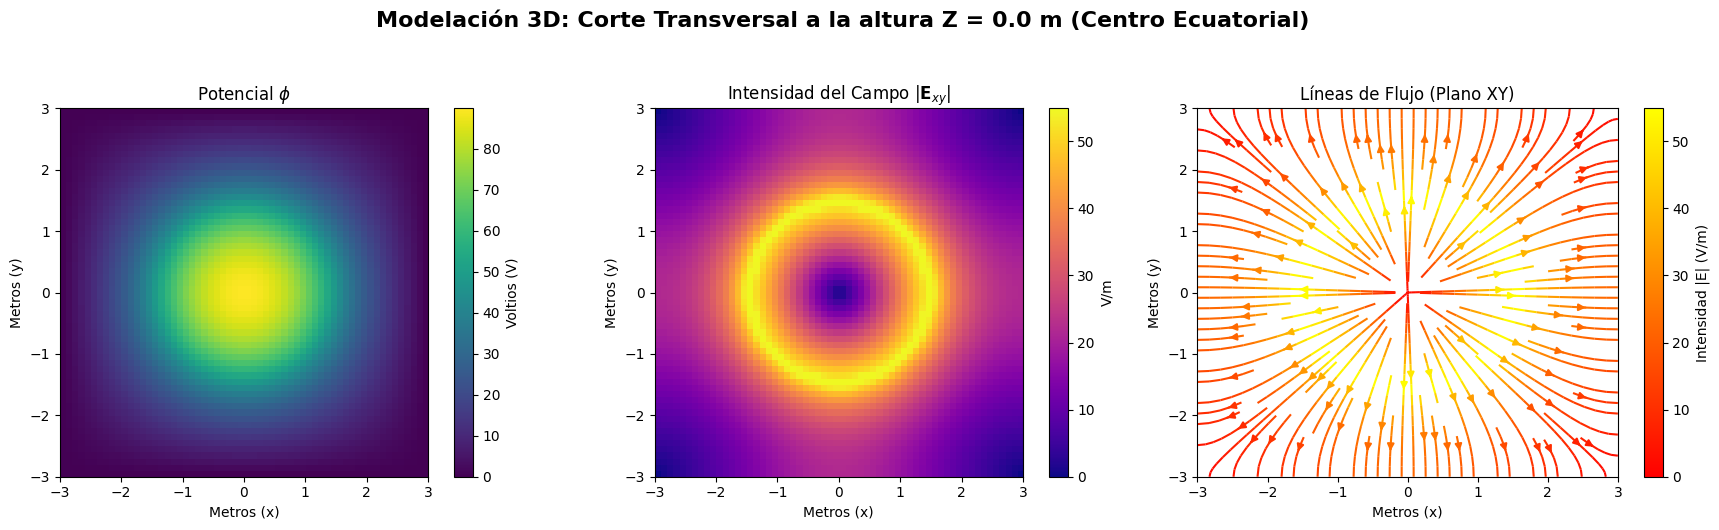

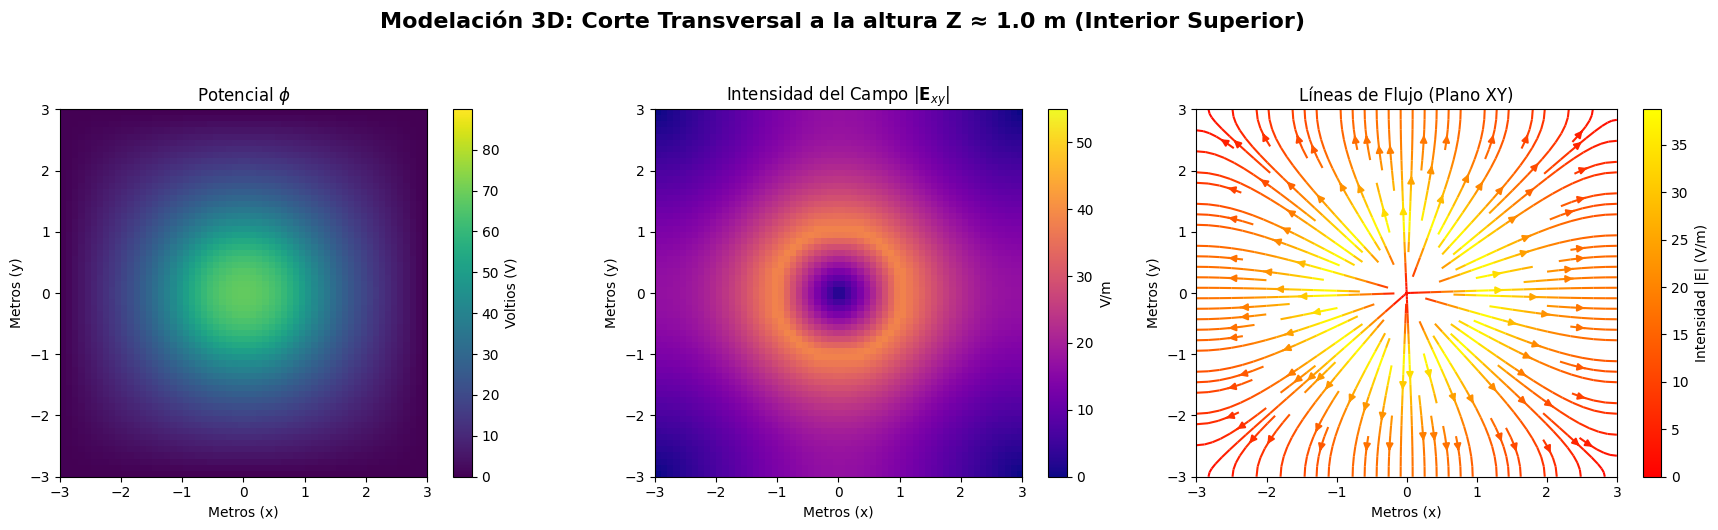

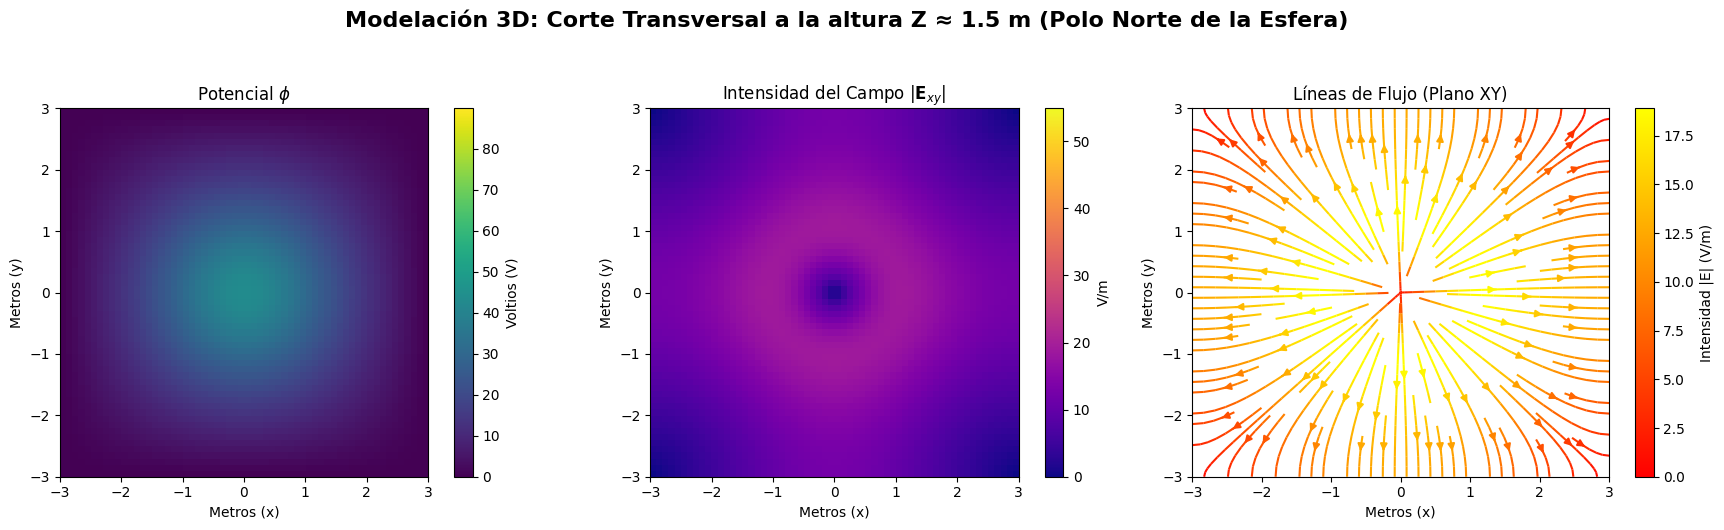

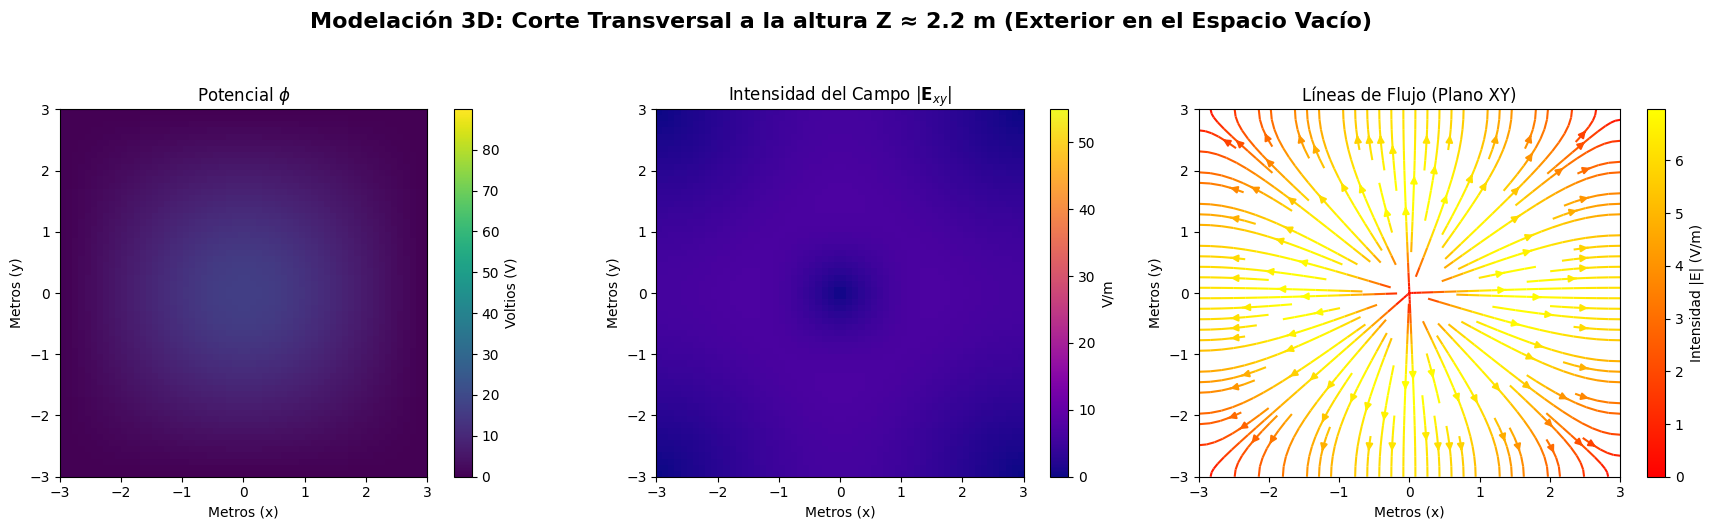

In [47]:
# Modelación 3D: Esfera Uniforme

# Configuración de la Malla 3D
metros = 5 
Lx, Ly, Lz = 1.2 * metros, 1.2 * metros, 1.2 * metros 

# Reducimos la resolución porque consume mucha memoria
Mx, My, Mz = 60, 60, 60 
dx = Lx / (Mx - 1)
dy = Ly / (My - 1)
dz = Lz / (Mz - 1)
h = dx # Asumimos dx = dy = dz
e_0 = 8.8541878128e-12

# Arreglos 1D
x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
z = np.linspace(-Lz/2, Lz/2, Mz)

# Malla 3D (Cubo de datos)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Distancia radial 3D (Teorema de Pitágoras en 3 ejes)
R_3d = np.sqrt(X**2 + Y**2 + Z**2)

# Geometría 3D: Esfera Sólida
rho_3d = np.zeros((Mx, My, Mz))
Q0 = 1e-9 # Carga constante
radio_esfera = 1.5 

mask_esfera = (R_3d <= radio_esfera)
rho_3d[mask_esfera] = Q0

# Resolución Numérica 3D (SOR Rojo-Negro)
phi_3d = np.zeros((Mx, My, Mz))
omega = 1.9
tolerancia = 1e-5
error_sor = 1.0
iteraciones_sor = 0

# Máscaras 3D
I, J, K = np.indices(phi_3d.shape)
interior = np.zeros_like(phi_3d, dtype=bool)
interior[1:-1, 1:-1, 1:-1] = True # Protegemos todas las "paredes" del cubo

mask_rojo = interior & ((I + J + K) % 2 == 0)
mask_negro = interior & ((I + J + K) % 2 == 1)

while error_sor > tolerancia and iteraciones_sor < 5000:
    phi_old = phi_3d.copy()
    
    # Actualización ROJAS en 3D (Factor de 1/6 en lugar de 1/4)
    promedio = np.zeros_like(phi_3d)
    promedio[1:-1, 1:-1, 1:-1] = (1.0/6.0) * (
        phi_3d[2:, 1:-1, 1:-1] + phi_3d[:-2, 1:-1, 1:-1] + 
        phi_3d[1:-1, 2:, 1:-1] + phi_3d[1:-1, :-2, 1:-1] + 
        phi_3d[1:-1, 1:-1, 2:] + phi_3d[1:-1, 1:-1, :-2] + 
        (h**2 * rho_3d[1:-1, 1:-1, 1:-1] / e_0)
    )
    phi_3d[mask_rojo] = (1 - omega) * phi_3d[mask_rojo] + omega * promedio[mask_rojo]
    
    # Actualización NEGRAS en 3D
    promedio[1:-1, 1:-1, 1:-1] = (1.0/6.0) * (
        phi_3d[2:, 1:-1, 1:-1] + phi_3d[:-2, 1:-1, 1:-1] + 
        phi_3d[1:-1, 2:, 1:-1] + phi_3d[1:-1, :-2, 1:-1] + 
        phi_3d[1:-1, 1:-1, 2:] + phi_3d[1:-1, 1:-1, :-2] + 
        (h**2 * rho_3d[1:-1, 1:-1, 1:-1] / e_0)
    )
    phi_3d[mask_negro] = (1 - omega) * phi_3d[mask_negro] + omega * promedio[mask_negro]
    
    error_sor = np.max(np.abs(phi_3d - phi_old))
    iteraciones_sor += 1

# Cálculo del Campo Vectorial 3D
Ex, Ey, Ez = np.gradient(-phi_3d, dx, dy, dz)

# Visualización: Múltiples Cortes Transversales (Slicing)

# Calculamos algunos índices representativos a lo largo del eje Z
mid_z = Mz // 2         # Z = 0.0 m (Centro exacto ecuatorial)
cuarto_z = mid_z + 10   # Z ≈ 1.0 m (Corte superior dentro de la esfera)
borde_z = mid_z + 15    # Z ≈ 1.5 m (Justo en el "Polo Norte" de la esfera)
afuera_z = mid_z + 22   # Z ≈ 2.2 m (Flotando en el espacio, fuera de la esfera)

# Creamos una lista con los cortes que queremos analizar
cortes_a_visualizar = [
    (mid_z, "Z = 0.0 m (Centro Ecuatorial)"),
    (cuarto_z, "Z ≈ 1.0 m (Interior Superior)"),
    (borde_z, "Z ≈ 1.5 m (Polo Norte de la Esfera)"),
    (afuera_z, "Z ≈ 2.2 m (Exterior en el Espacio Vacío)")
]

# Buscamos el valor máximo global del potencial y del campo en todo el cubo 3D 
# para mantener la misma escala de colores en todas las fotos.
max_phi_global = np.max(phi_3d)
max_E_global = np.max(np.sqrt(Ex**2 + Ey**2))

for indice_z, titulo_corte in cortes_a_visualizar:
    
    # Extraemos las rebanadas en 2D y aplicamos la Transpuesta (.T) para Matplotlib
    phi_slice = phi_3d[:, :, indice_z].T
    Ex_slice = Ex[:, :, indice_z].T
    Ey_slice = Ey[:, :, indice_z].T
    X_slice = X[:, :, indice_z].T
    Y_slice = Y[:, :, indice_z].T
    
    # Magnitud del campo eléctrico proyectado en este plano 2D (solo Ex y Ey)
    E_mag_slice = np.sqrt(Ex_slice**2 + Ey_slice**2)
    
    # Generamos los 3 paneles
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Modelación 3D: Corte Transversal a la altura {titulo_corte}", 
                 fontsize=16, fontweight='bold', y=1.05)

    # Panel 1: Mapa del Potencial Escalar
    im0 = ax[0].imshow(phi_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='viridis', vmin=0, vmax=max_phi_global)
    ax[0].set_title(r"Potencial $\phi$")
    ax[0].set_xlabel('Metros (x)')
    ax[0].set_ylabel('Metros (y)')
    plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

    # Panel 2: Mapa de Intensidad del Campo Eléctrico
    im1 = ax[1].imshow(E_mag_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='plasma', vmin=0, vmax=max_E_global)
    ax[1].set_title(r"Intensidad del Campo $|\mathbf{E}_{xy}|$")
    ax[1].set_xlabel('Metros (x)')
    ax[1].set_ylabel('Metros (y)')
    plt.colorbar(im1, ax=ax[1], label='V/m')

    # Panel 3: Líneas de flujo del campo eléctrico
    # Solo mostramos flechas si hay algo de campo, de lo contrario streamplot podría quejarse
    if np.max(E_mag_slice) > 1e-6:
        st = ax[2].streamplot(X_slice, Y_slice, Ex_slice, Ey_slice, color=E_mag_slice, 
                              cmap='autumn', density=1.2, linewidth=1.5)
        fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')
    
    ax[2].set_title("Líneas de Flujo (Plano XY)")
    ax[2].set_xlabel('Metros (x)')
    ax[2].set_ylabel('Metros (y)')
    ax[2].set_xlim([-Lx/2, Lx/2])
    ax[2].set_ylim([-Ly/2, Ly/2])

    plt.tight_layout()
    plt.show()
plt.show()

## Coordenadas Esféricas mapeadas a 3D:  
Resolver un cubo cartesiano de $60\times60\times60$ ya es demandante computacionalmente. Si quisiéramos alta resolución ($200^3$), requeriríamos calcular 8 millones de puntos por iteración, lo cual es ineficiente para problemas con simetría.  
Para cumplir con la extensión propuesta en la pauta, resolveremos la esfera uniformemente cargada explorando su simetría radial mediante coordenadas esféricas.
La ecuación de Poisson se reduce a una dimensión dependiente solo del radio $r$

<div style="background-color: #d9ffd4; padding: 20px; border-radius: 10px;">
<h1 style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center;">Anexo Teórico</h1>
<p style="color: #2F4F4F; font-family: Calibri, Courier, monospace; text-align: center; font-size: 24px;">
¿De dónde nace la Ecuación de Poisson en 1D?
</p>
</div>

Para entender cómo llegar a la forma 1D, necesitamos juntar dos de los conceptos más fundamentales del electromagnetismo. Vamos a realizarlo paso a paso, imaginando que nuestro universo es solo una línea recta (el eje $x$).
* Paso 1: La Ley de Gauss:<br>La primera ley que necesitamos es la Ley de Gauss en su forma diferencial. Esta ley nos dice que las cargas eléctricas son fuentes que emiten o absorben campo eléctrico. Matemáticamente se escribe con el operador divergencia ($\nabla \cdot$):<br>$$\nabla \cdot \vec{E} = \frac{\rho}{\epsilon_0}$$Como estamos obligando a nuestro universo a ser de una sola dimensión (el eje $x$), el campo eléctrico no puede apuntar ni hacia arriba ni hacia el fondo. Solo existe el componente $E_x$. Por lo tanto, el operador divergencia se simplifica a una derivada normal:$$\frac{dE_x}{dx} = \frac{\rho(x)}{\epsilon_0}$$

* Paso 2: El Potencial Eléctrico:<br>El campo es exactamente igual a qué tan inclinada está nuestra montaña de energía.$$\vec{E} = -\vec{\nabla} \phi$$ De nuevo, como estamos en nuestro universo 1D donde solo existe la línea $x$, se reduce a una simple derivada: $$E_x = -\frac{d\phi}{dx}$$

* Paso 3: Combinación:<br>Ahora tenemos la derivada del campo = Carga Campo = Derivada negativa del potencial. Simplemente insertamos la segunda ecuación dentro de la primera tomando nuestro $E_x$ del Paso 2 y lo metemos en la Ley de Gauss del Paso 1:
$$\frac{d}{dx} \left( -\frac{d\phi}{dx} \right) = \frac{\rho(x)}{\epsilon_0}$$


* Paso 4: Ecuación final: <br>Al aplicar la derivada a otra derivada, obtenemos la segunda derivada.<br>Sacamos el signo negativo hacia el otro lado de la igualdad y listo:   


$$
\frac{d^2\phi}{dx^2} = -\frac{\rho(x)}{\epsilon_0}
$$
<br>¿Qué significa esto físicamente para nuestro código? La segunda derivada representa la curvatura o concavidad de una gráfica. La ecuación de Poisson nos está diciendo que la curvatura de nuestro $\phi$ en cualquier punto del espacio está dictada exactamente por la cantidad de carga ($\rho$) que hay ahí mismo.

* Paso 5: Sustitución: Si intentamos meter la ecuación original de coordenadas esféricas en nuestro código, nos topamos con un problema: tiene divisiones por $r^2$ y una mezcla de primeras y segundas derivadas. Eso hace que el método de diferencias finitas sea complejo de programar. Al hacer una sustitución de $U(r) = r\cdot\phi(r)$, transformamos una ecuación esférica en una ecuación que se ve y se programa exactamente igual que una simple línea recta en 1D.  
Mediante la sustitución $U(r) = r\cdot\phi(r)$, la ecuación se linealiza a
$$
\frac{d^2U}{dr^2} = -\frac{r\rho(r)}{\epsilon_0}
$$

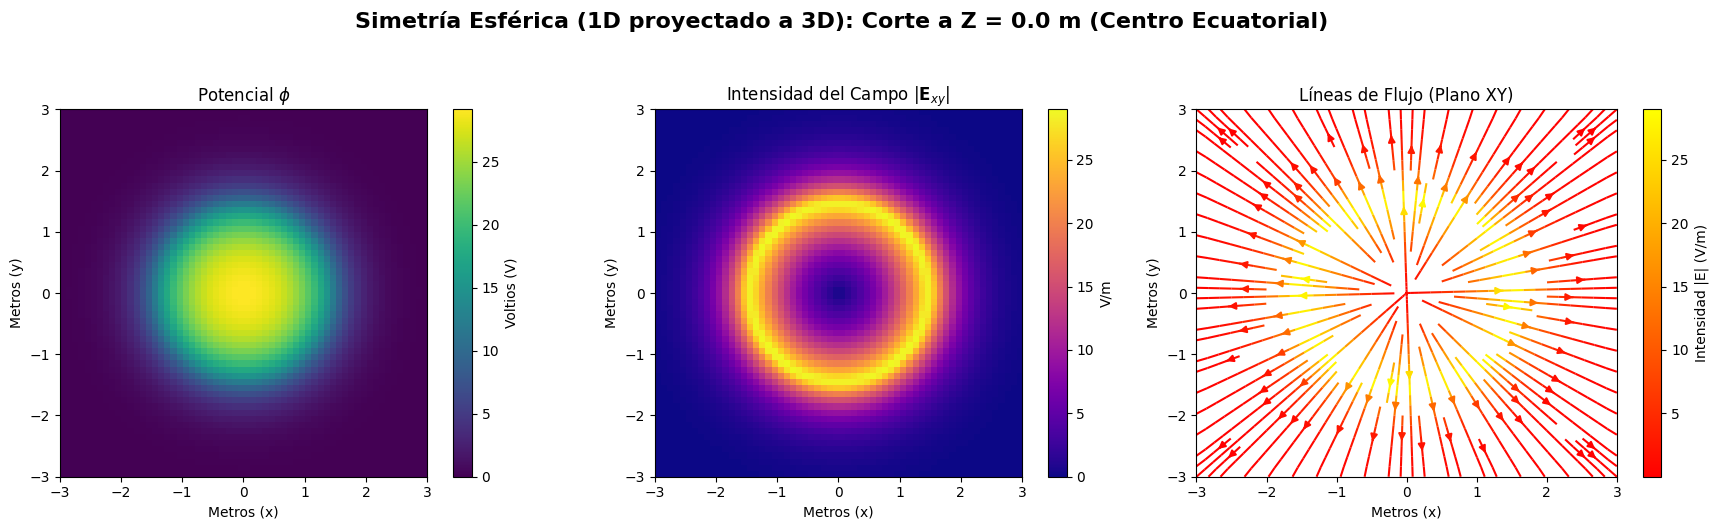

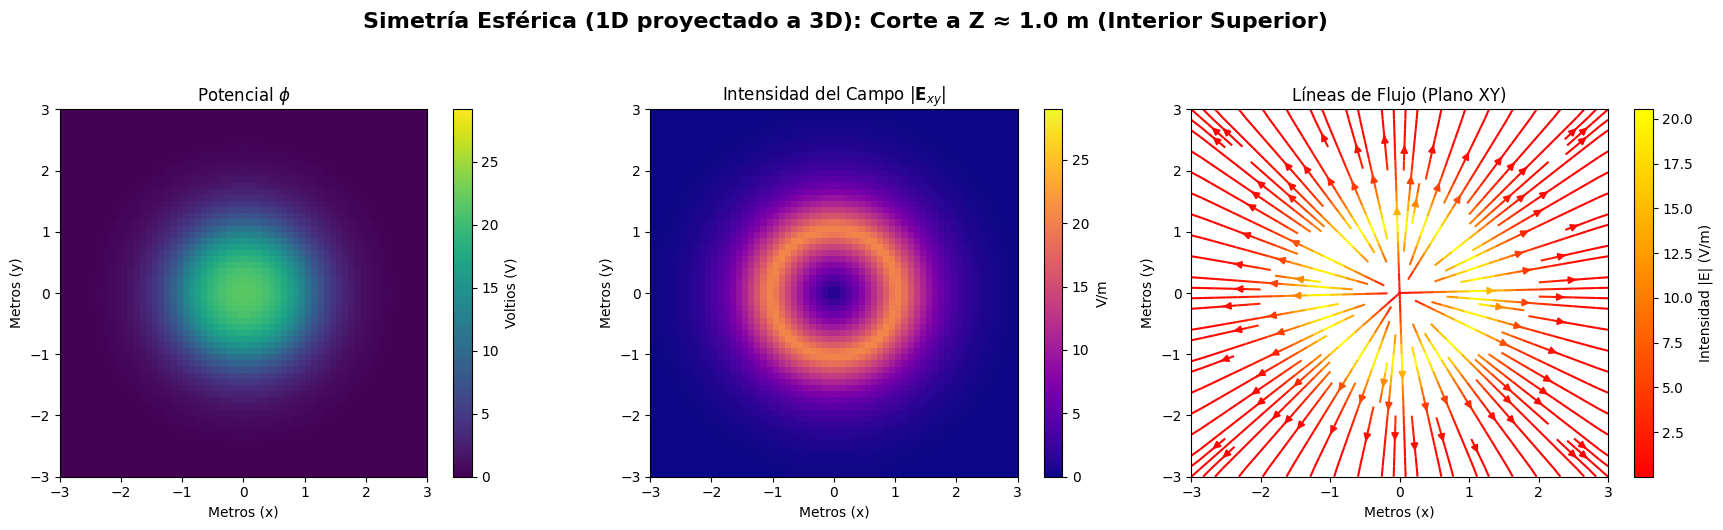

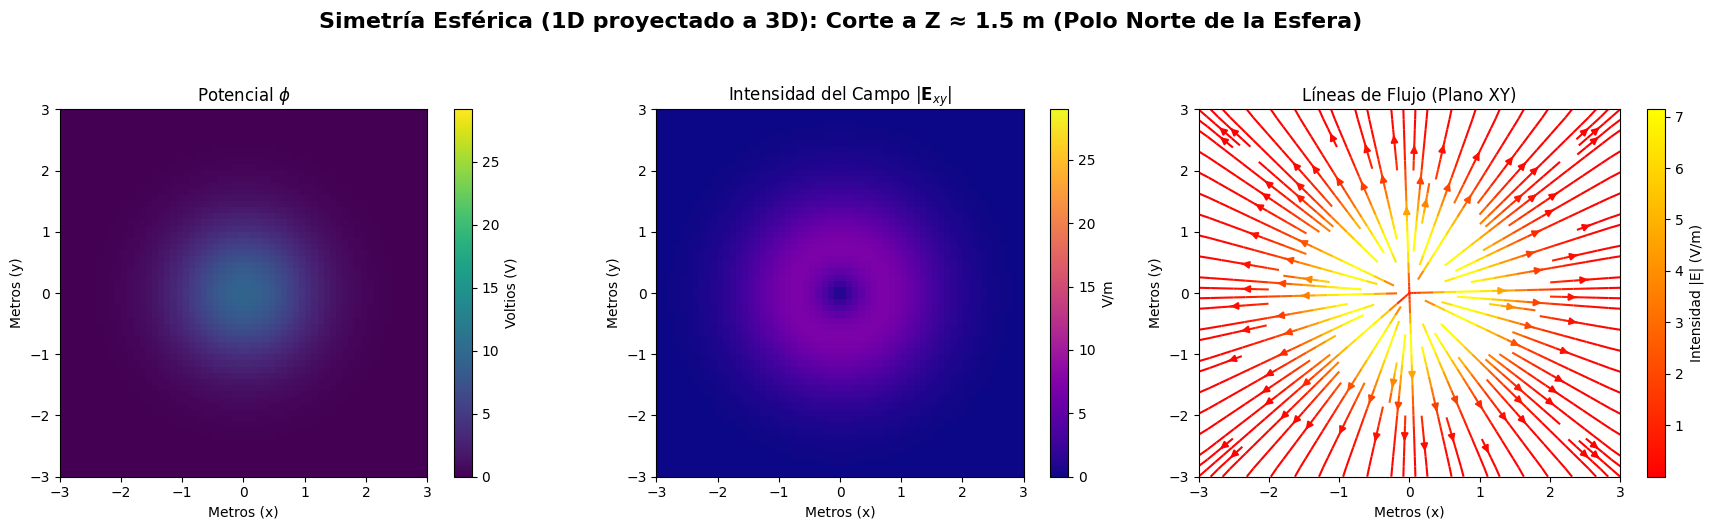

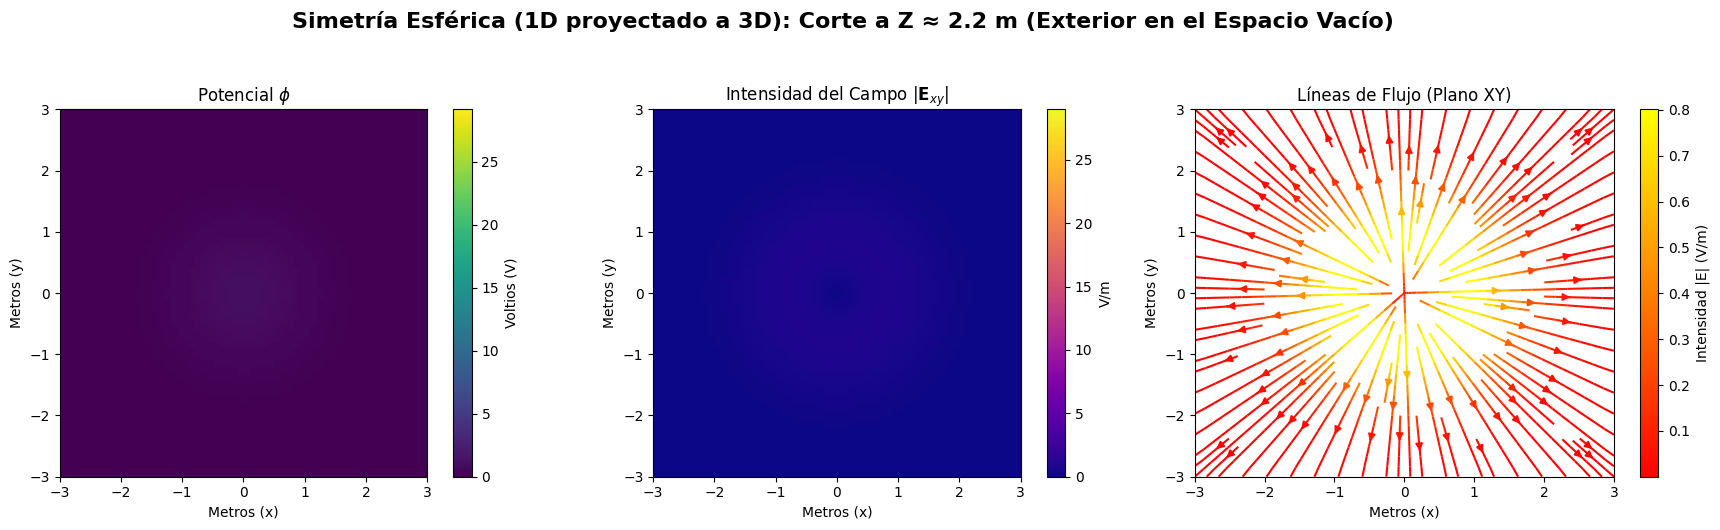

In [19]:
# Malla Cartesiana 3D de Referencia
metros = 5 
Lx, Ly, Lz = 1.2 * metros, 1.2 * metros, 1.2 * metros 
Mx, My, Mz = 60, 60, 60  
dx, dy, dz = Lx/(Mx-1), Ly/(My-1), Lz/(Mz-1)
e_0 = 8.8541878128e-12
Q0 = 1e-9
radio_esfera = 1.5 

x = np.linspace(-Lx/2, Lx/2, Mx)
y = np.linspace(-Ly/2, Ly/2, My)
z = np.linspace(-Lz/2, Lz/2, Mz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Calculamos el radio exacto de cada punto en el espacio 3D
R_3d = np.sqrt(X**2 + Y**2 + Z**2)


# SOLUCIÓN EN COORDENADAS ESFÉRICAS (1D)
Nr = 1000 # Usamos 1000 puntos solo para el radio (resolución altísima)
r_max = np.max(R_3d) + 0.1 
r_esferico = np.linspace(0, r_max, Nr)
dr = r_esferico[1] - r_esferico[0]

# Densidad 1D
rho_1d = np.zeros(Nr)
rho_1d[r_esferico <= radio_esfera] = Q0

# Iteración vectorizada en 1D para U(r)
U = np.zeros(Nr)
for iteracion in range(20000):
    U_old = U.copy()
    U[1:-1] = 0.5 * (U[2:] + U[:-2] + (dr**2 * r_esferico[1:-1] * rho_1d[1:-1]) / e_0)
    U[-1] = 0 # Condición de frontera (phi=0 en el infinito)
    
    if np.max(np.abs(U - U_old)) < 1e-7:
        break

# Recuperamos phi(r) = U(r)/r
phi_esferica_1d = np.zeros(Nr)
phi_esferica_1d[1:] = U[1:] / r_esferico[1:]
phi_esferica_1d[0] = phi_esferica_1d[1] # El centro exacto


# PROYECCIÓN DE 1D A 3D
# Usamos interpolación para asignar el valor de phi a cada punto del cubo 3D según su radio
phi_3d_esferica = np.interp(R_3d, r_esferico, phi_esferica_1d)

# Calculamos el Campo Vectorial en la nueva matriz 3D
Ex, Ey, Ez = np.gradient(-phi_3d_esferica, dx, dy, dz)


# VISUALIZACIÓN DE LOS CORTES
mid_z = Mz // 2         # Z = 0.0 m
cuarto_z = mid_z + 10   # Z ≈ 1.0 m
borde_z = mid_z + 15    # Z ≈ 1.5 m
afuera_z = mid_z + 22   # Z ≈ 2.2 m

cortes_a_visualizar = [
    (mid_z, "Z = 0.0 m (Centro Ecuatorial)"),
    (cuarto_z, "Z ≈ 1.0 m (Interior Superior)"),
    (borde_z, "Z ≈ 1.5 m (Polo Norte de la Esfera)"),
    (afuera_z, "Z ≈ 2.2 m (Exterior en el Espacio Vacío)")
]

max_phi_global = np.max(phi_3d_esferica)
# Proyectamos la magnitud del campo sobre el plano XY para la visualización
max_E_global = np.max(np.sqrt(Ex**2 + Ey**2)) 

for indice_z, titulo_corte in cortes_a_visualizar:
    
    # Extraemos las rebanadas y transponemos para Matplotlib
    phi_slice = phi_3d_esferica[:, :, indice_z].T
    Ex_slice = Ex[:, :, indice_z].T
    Ey_slice = Ey[:, :, indice_z].T
    X_slice = X[:, :, indice_z].T
    Y_slice = Y[:, :, indice_z].T
    
    E_mag_slice = np.sqrt(Ex_slice**2 + Ey_slice**2)
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Simetría Esférica (1D proyectado a 3D): Corte a {titulo_corte}", 
                 fontsize=16, fontweight='bold', y=1.05)

    # Panel 1
    im0 = ax[0].imshow(phi_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='viridis', vmin=0, vmax=max_phi_global)
    ax[0].set_title(r"Potencial $\phi$")
    ax[0].set_xlabel('Metros (x)')
    ax[0].set_ylabel('Metros (y)')
    plt.colorbar(im0, ax=ax[0], label='Voltios (V)')

    # Panel 2
    im1 = ax[1].imshow(E_mag_slice, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower', 
                       cmap='plasma', vmin=0, vmax=max_E_global)
    ax[1].set_title(r"Intensidad del Campo $|\mathbf{E}_{xy}|$")
    ax[1].set_xlabel('Metros (x)')
    ax[1].set_ylabel('Metros (y)')
    plt.colorbar(im1, ax=ax[1], label='V/m')

    # Panel 3
    if np.max(E_mag_slice) > 1e-6:
        st = ax[2].streamplot(X_slice, Y_slice, Ex_slice, Ey_slice, color=E_mag_slice, 
                              cmap='autumn', density=1.2, linewidth=1.5)
        fig.colorbar(st.lines, ax=ax[2], label='Intensidad |E| (V/m)')
    
    ax[2].set_title("Líneas de Flujo (Plano XY)")
    ax[2].set_xlabel('Metros (x)')
    ax[2].set_ylabel('Metros (y)')
    ax[2].set_xlim([-Lx/2, Lx/2])
    ax[2].set_ylim([-Ly/2, Ly/2])

    plt.tight_layout()
    plt.show()

<div style="background-color: #d9ffd4; padding: 20px; border-radius: 10px;"><h1 style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center; margin-bottom: 0;">Análisis, conclusiones y Discusión Final</h1></div>

A lo largo de este proyecto, hemos construido un modelo numérico robusto partiendo desde conceptos electrostáticos fundamentales hasta simulaciones tridimensionales. El análisis de nuestras simulaciones nos permite concluir lo siguiente:  
1. **El comportamiento del potencial en distribuciones vacías (El Anillo)**:<br>Al modelarse el anillo de carga uniforme, el mapa de calor del potencial ($\phi$) reveló un círculo sólido y brillante en lugar de una forma anular hueca. En el interior vacío de una distribución de carga cerrada, el potencial eléctrico no cae a cero, sino que se mantiene en un valor constante. Dado que el campo eléctrico es el gradiente de este potencial ($E = -\nabla\phi$), la ausencia de inclinación en esta meseta central da como resultado un campo eléctrico nulo ($|\vec{E}| = 0$) en el interior del anillo, confirmando la teoría del apantallamiento electrostático (Jaula de Faraday).

2. **Asimetría en densidades no uniformes**:<br>La extensión a un anillo dipolar con carga variable $\rho(\theta) \propto \sin(\theta)$ demostró la capacidad del modelo para manejar asimetrías. Físicamente, visualizamos cómo las líneas de campo viajan por el espacio interior directamente desde el polo positivo hacia el negativo. El algoritmo asimiló sin problemas esta distribución, generando un plano de equipotencial $0\text{ V}$ exacto en la zona ecuatorial (neutra), lo cual refleja un equilibrio preciso en la iteración numérica.

3. **Superposición y el campo central nulo:** <br>Al evaluar simultáneamente un disco sólido y un anillo dipolar en el mismo espacio, el método de diferencias finitas procesa la superposición de campos de manera automática sin recurrir a integraciones complejas. Es de particular interés notar que, a pesar de la agresiva distorsión que genera el anillo exterior sobre las líneas de flujo, el centro exacto del disco uniforme mantiene una magnitud de campo eléctrico **igual a cero**. Esto se debe a que, en el origen, las fuerzas repulsivas emanadas por la propia simetría radial del disco se cancelan mutuamente en todas las direcciones, superando la influencia del campo externo en ese punto específico.

4. **Dificultades del salto a 3D y la importancia del "Slicing":** <br>Escalar el modelo de 2D a 3D introdujo un reto de memoria y procesamiento (pasando de $\approx 40000$ a más de $216000$ nodos), lo que nos obligó a reestructurar el operador Laplaciano para considerar 6 vecinos ortogonales. En tres dimensiones, la visualización de datos requiere realizar "cortes transversales" (slicing) sobre los planos. Al iterar estos cortes a lo largo del eje z, observamos cómo el radio de la zona amarilla (potencial máximo) se reduce paulatinamente, confirmando visualmente que estamos modelando un objeto esférico confinado en el espacio y no un cilindro infinito.

5. **Cartesianas vs Esféricas, Resolución Numérica y Líneas de Flujo:** <br>La comparación entre el cubo cartesiano 3D y la proyección esférica 1D expuso diferencias algorítmicas:
* La zona amarilla en las lineas de campo: En el modelo cartesiano de baja resolución, la frontera curva de la esfera se discretiza en escalones, lo que suaviza numéricamente el gradiente y hace que la zona amarilla del campo máximo se vea artificialmente ensanchada. La solución esférica 1D, al tener 1000 puntos de resolución, calcula un pico de intensidad afilado, matemáticamente concentrado estrictamente en el radio exacto de la esfera.
* Líneas de flujo: En el modelo cartesiano, las líneas de flujo se curvan antinaturalmente en el exterior intentando adaptarse a la "caja" cuadrada que define nuestra matriz. En la proyección esférica, al estar la condición de frontera mapeada radialmente en el infinito virtual, las líneas divergen de forma recta y simétrica.

6. **Algoritmos Numéricos y la Ecuación de Poisson:**<br>La Ecuación de Poisson demostró ser una excelente herramienta para conectar fuentes de carga con la topografía de la energía espacial. Sin embargo, su resolución directa se complica en geometrías irregulares. Aquí radicó la importancia de los métodos numéricos: transicionar del método de Jacobi, al método SOR, e implementar un esquema vectorizado de Rojo-Negro, fue lo que convirtió un problema en una simulación de alto rendimiento.

7. **El Rol Crítico de las Condiciones de Frontera:** <br>Por último, el éxito de toda la simulación descansó sobre las condiciones de frontera de Dirichlet ($\phi \rightarrow 0$ en los bordes). Estas fronteras actúan como el contenedor de nuestro "universo" simulado. Sin ellas, el método iterativo divergiría hacia el infinito al no tener un punto de referencia para el cero de energía. Al anclar los bordes, obligamos a las líneas del campo eléctrico a tener un destino, permitiendo que la iteración alcance la convergencia y un estado de equilibrio físico realista.